# DSB Assignment — Part II, Market Research (Q1–Q16)
**Global Events, Commodities and Currency Markets** · *Group 8*

Part II explains how major global events help interpret the data patterns found in Part I. Every answer is linked to at least one specific Part I chart or table. All sixteen Part II questions (Q1–Q16) are answered in this single notebook.

In [1]:
# --- Bootstrap shared module + load data (relative paths only) ---
import os, sys
_d = os.getcwd()
while _d != os.path.dirname(_d) and not os.path.exists(os.path.join(_d, "src", "dsb_utils.py")):
    _d = os.path.dirname(_d)
sys.path.insert(0, os.path.join(_d, "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Markdown, display
import dsb_utils as dsb

dsb.apply_style()
QDIR = os.path.join(dsb.ROOT, "part2")
FIGDIR = os.path.join(QDIR, "figures"); os.makedirs(FIGDIR, exist_ok=True)
TBLDIR = os.path.join(QDIR, "tables");  os.makedirs(TBLDIR, exist_ok=True)
COLORS = dsb.COLORS

commodities = dsb.load_all_commodities()
brent, gold, silver = commodities["Brent Oil"], commodities["Gold"], commodities["Silver"]
swift = dsb.load_swift()

# annual averages reused throughout Part II
ba = brent.groupby("Year")["Value"].mean()
ga = gold.groupby("Year")["Value"].mean()
sa = silver.groupby("Year")["Value"].mean()
print("Loaded commodities + SWIFT; annual-average series ready.")

Loaded commodities + SWIFT; annual-average series ready.


---
## A. Event Identification (Q1–Q3)
Three major global events, an annotated event timeline, and the event most directly connected to Brent Oil. These link to the Part I trend and annual-average charts.

### Q1 — Three major global events affecting commodity & currency markets

Three events stand out in the data as clearly linked to commodity or currency moves.

**Russia-Ukraine war and SWIFT sanctions (Feb 2022).** Brent's monthly average was already elevated at \$104.72 in January 2022 and climbed to a peak of \$129.22 in May before easing back; the full 2022 average came in at \$106.45, up 28.2% from \$83.02 in 2021. Russia's exclusion from SWIFT also pushed more Russia-China trade into RMB settlement - part of why CNY now sits at rank 5 (3.10% of global payments, April 2026).

**COVID-19 and global lockdowns (2020).** Brent crashed to \$24.77 in April 2020 and the 2020 annual average fell 33.6% to \$49.19, the sharpest demand shock in the dataset. Gold and silver moved the opposite way, up 27.0% and 27.1%, as investors rotated into safe havens.

**Central-bank gold accumulation and de-dollarisation (2022-2026).** Gold rose from roughly \$1,800 (2022) to a \$5,277.89 peak in February 2026, about a 193% move, which lines up with widely reported central-bank buying (China, India, Turkey, Poland) diversifying away from USD reserves. USD still leads SWIFT payments at 51.14% (April 2026), but CNY's share and offshore RMB activity in Hong Kong have both been creeping up.

### Q2 — Timeline of selected events


=== PART II — Q2: Event Timeline ===
 Period                               Event      Oil effect                  Gold effect
1973–74                        OPEC embargo         +141.5%                 Surge begins
1979–81    Iran Revolution\n+ Iran-Iraq War     Spike >$130                +89.3% (1979)
   1986                      OPEC price war          −49.3%                 Consolidates
1990–91                            Gulf War     Jump to $98                  Slight rise
2008–09             Global Financial Crisis            −35%                         +24%
2014–16                US shale\noversupply            −46%                 Consolidates
   2020                            COVID-19          −33.6%                       +27.0%
   2022     Russia-Ukraine\nWar + Sanctions          +28.2%                 Holds $1,800
2022–26 Gold accumulation\nDe-dollarisation Gradual decline +44% (2025)\n+41% (2026 YTD)


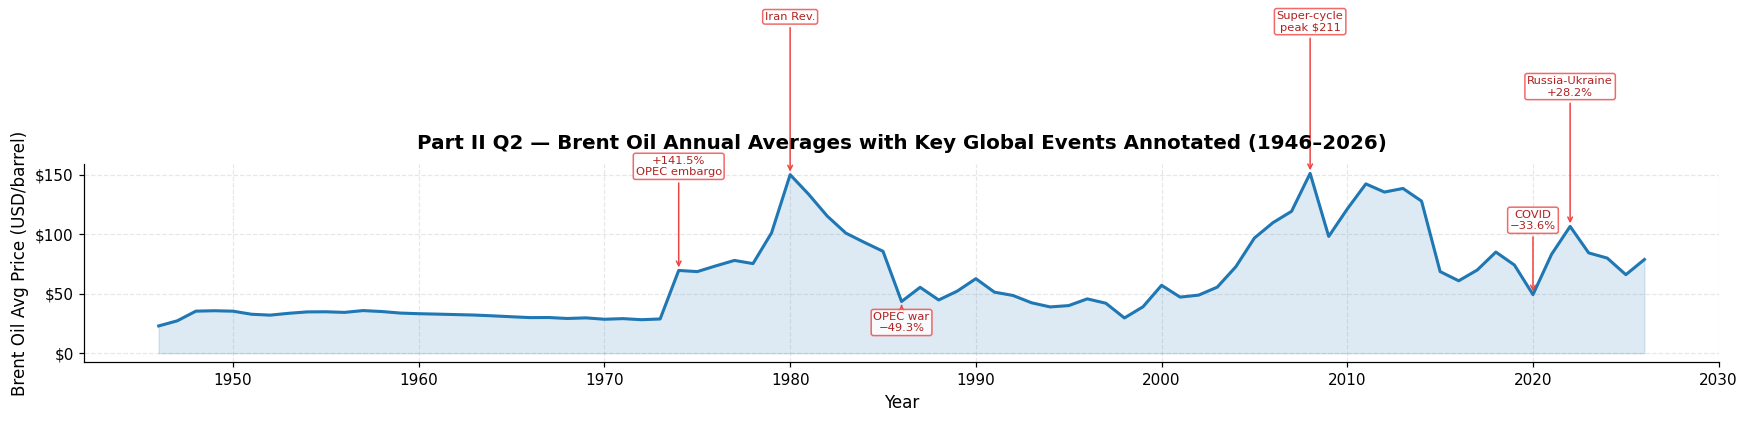

In [3]:
# Part II Q2 — Event Timeline Table & Chart ────────────────────────
timeline_data = {
    'Period':    ['1973–74', '1979–81', '1986',  '1990–91', '2008–09', '2014–16', '2020', '2022',   '2022–26'],
    'Event':     ['OPEC embargo', 'Iran Revolution\n+ Iran-Iraq War', 'OPEC price war',
                  'Gulf War', 'Global Financial Crisis', 'US shale\noversupply',
                  'COVID-19', 'Russia-Ukraine\nWar + Sanctions', 'Gold accumulation\nDe-dollarisation'],
    'Oil effect':    ['+141.5%', 'Spike >$130', '−49.3%', 'Jump to $98', '−35%', '−46%', '−33.6%', '+28.2%', 'Gradual decline'],
    'Gold effect':   ['Surge begins', '+89.3% (1979)', 'Consolidates', 'Slight rise', '+24%', 'Consolidates', '+27.0%', 'Holds $1,800', '+44% (2025)\n+41% (2026 YTD)'],
    'Silver effect': ['Follows gold', 'Peaks $35.52', 'Low volatility', 'Slight rise', '+21%', 'Falls −40%', '+27.1%', '−13.2%', '+47.5% (2025)\n+131.5% (2026 YTD)'],
    'Currency':      ['USD weakens', 'USD inflation\nVolcker shock', 'Limited impact', 'USD flows', 'USD safe haven', 'USD strengthens', 'Rate cuts global', 'CNY rises\nBRICS talks start', 'CNY rank 5 (3.10%)'],
}
timeline_df = pd.DataFrame(timeline_data)
print("\n=== PART II — Q2: Event Timeline ===")
print(timeline_df[['Period', 'Event', 'Oil effect', 'Gold effect']].to_string(index=False))

# Visual: Annotated oil chart with event flags
fig, ax = plt.subplots(figsize=(16, 6))

ax.fill_between(ba.index, ba.values, alpha=0.15, color=COLORS['oil'])
ax.plot(ba.index, ba.values, color=COLORS['oil'], linewidth=2)

events = [
    (1974, "+141.5%\nOPEC embargo", 80),
    (1980, "Iran Rev.", 130),
    (1986, "OPEC war\n−49.3%", -25),
    (2008, "Super-cycle\npeak $211", 120),
    (2020, "COVID\n−33.6%", 55),
    (2022, "Russia-Ukraine\n+28.2%", 110),
]
for yr, label, y_off in events:
    y_val = ba.loc[yr] if yr in ba.index else ba.iloc[(ba.index - yr).abs().argmin()]
    ax.annotate(label, xy=(yr, y_val), xytext=(yr, y_val + y_off),
                arrowprops=dict(arrowstyle='->', color='#ef4444', lw=1),
                color='#b22222', fontsize=7.5, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#ef4444', alpha=0.8))

ax.set_title("Part II Q2 — Brent Oil Annual Averages with Key Global Events Annotated (1946–2026)", pad=10)
ax.set_ylabel("Brent Oil Avg Price (USD/barrel)")
ax.set_xlabel("Year")
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "pt2_q2_timeline_oil.png"), dpi=150, bbox_inches='tight')
plt.show()
timeline_df.to_csv(os.path.join(TBLDIR, "PartII_Q2_event_timeline.csv"), index=False)


### Q3 — Event most directly connected to Brent Oil

The Russia-Ukraine war (February 2022) is the event most directly and immediately tied to Brent Oil in this dataset. Russia is one of the world's largest crude exporters, and within weeks of the invasion Brent's monthly average moved from about \$105 in January 2022 to a peak of \$129 in May - a fast, supply-driven jump. The 2022 annual average of \$106.45 was the highest since 2012.

Other candidates don't fit as cleanly. The 1973-74 OPEC embargo produced an even bigger annual jump (+141.5%, from a \$28.76 base in 1973), but that's a much smaller, less liquid market decades removed from the rest of the dataset. The 2020 COVID crash (-33.6%) was a demand shock, not a supply one, and oil fully recovered afterward. The 2008 peak (\$211.21) built up over several years of a broader commodity supercycle rather than a single trigger.

What makes 2022 distinct is that it combined a physical loss of supply with sanctions that disrupted the trading infrastructure itself - the clearest single-event, single-direction move in the Brent series.

---
## A. Event Identification

### Q4 — Which event seems most directly connected to Gold or Silver prices? Explain why.

The event most connected to gold and silver is the post-2022 wave of central-bank gold buying tied to de-dollarisation. It lines up with the largest sustained move in either metal's series: on the Q14 gold chart and Q11 top-5 years table, gold's annual average climbs every year from 2022 to 2026, roughly tripling from \$1,798.96 to \$4,881.62. Silver follows the same path (Q12), up 47.5% in 2025 and 131.5% so far in 2026. Unlike the 2020 COVID spike, which was a one-year safe-haven jump that partly reversed, this is a multi-year climb - consistent with reserve managers gradually rotating out of dollars and into gold. The chart below marks the 2022-2026 accumulation period.

saved figure -> part2/figures/PartII_Q4_gold_accumulation.png


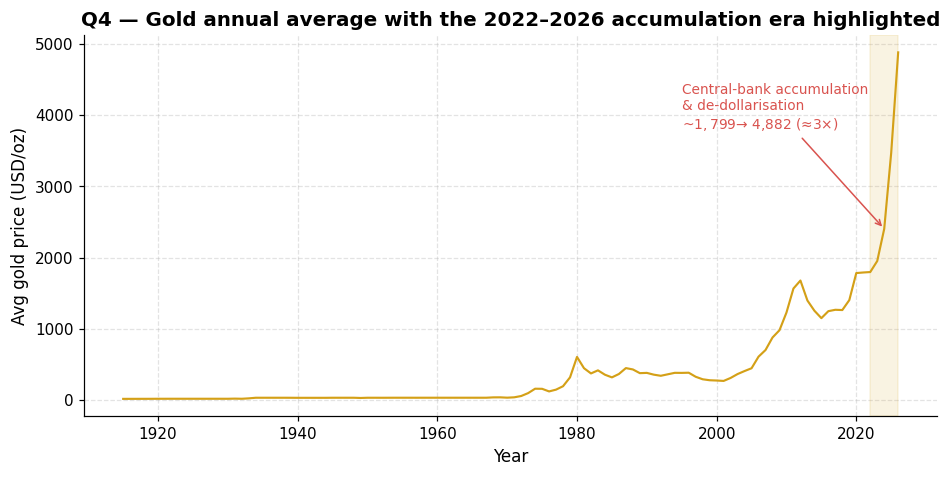

Gold annual avg: 2022 ≈ $1,799  ->  2026 ≈ $4,882  (x2.7)


In [5]:
# Supporting visual for Q4: gold annual average with the 2022-2026 accumulation era highlighted
fig, ax = plt.subplots()
ax.plot(ga.index, ga.values, color=dsb.COLORS["gold"], linewidth=1.4)
ax.axvspan(2022, 2026, color=dsb.COLORS["gold"], alpha=0.12)
ax.annotate("Central-bank accumulation\n& de-dollarisation\n~$1,799 → ~$4,882 (≈3×)",
            xy=(2024, ga.loc[2024]), xytext=(1995, ga.max()*0.78),
            arrowprops=dict(arrowstyle="->", color=dsb.COLORS["cny"]), fontsize=9, color=dsb.COLORS["cny"])
ax.set_title("Q4 — Gold annual average with the 2022–2026 accumulation era highlighted")
ax.set_xlabel("Year"); ax.set_ylabel("Avg gold price (USD/oz)")
dsb.save_fig(fig, "PartII_Q4_gold_accumulation", QDIR); plt.show()
print(f"Gold annual avg: 2022 ≈ ${ga.loc[2022]:,.0f}  ->  2026 ≈ ${ga.loc[2026]:,.0f}  (x{ga.loc[2026]/ga.loc[2022]:.1f})")

> **Cited Part I chart — Q14 Gold trend (from `14-26Q`):**
>
> ![Q14 Gold trend](../14-26Q/figures/Q14_gold_trend.png)

---
## B. Linking Events to Commodity Data

### Q5 — How could an oil supply shock or shipping disruption affect Brent Oil prices?

Oil trades on thin spare capacity, so a supply shock or shipping disruption pulls barrels off the market faster than demand can adjust, and prices gap up rather than drift. The clearest case here is the most recent month in the data: Brent drifts down through 2025 (from about \$75 to \$58) and then jumps from \$67.66 in February 2026 to \$102.86 in March - a 52% move in a single month, in line with a Strait of Hormuz-type shipping disruption. Roughly a fifth of the world's seaborne oil passes through that chokepoint, so even the threat of closure moves the whole price curve. The same shape - long calm stretches, then a sharp supply-driven spike - shows up earlier in the series too, around 1979-80, 2008 and 2022.

saved figure -> part2/figures/PartII_Q5_brent_recent.png


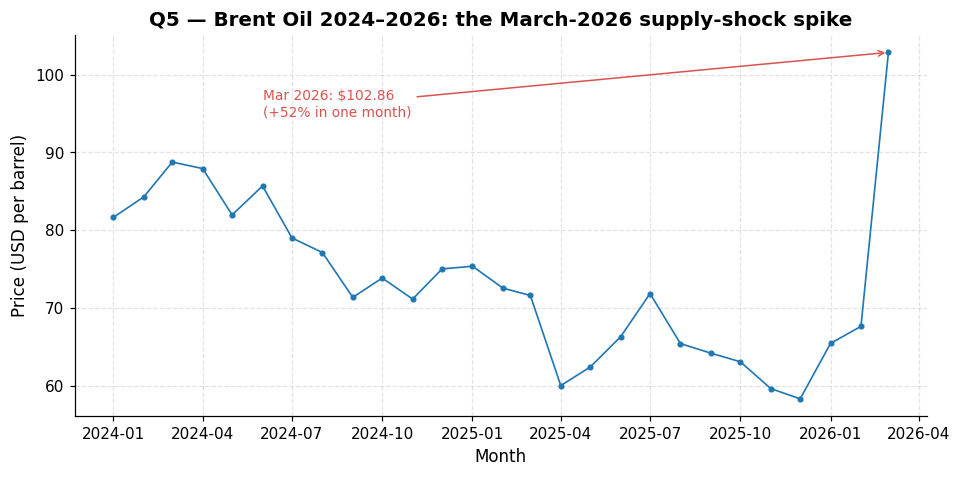

In [6]:
# Supporting visual for Q5: recent Brent monthly with the March-2026 supply-shock spike annotated
recent = brent[brent["Year"] >= 2024]
fig, ax = plt.subplots()
ax.plot(recent["Date"], recent["Value"], color=dsb.COLORS["oil"], marker="o", markersize=3, linewidth=1.1)
mar26 = brent.loc[brent["Date"] == pd.Timestamp("2026-03-01"), "Value"].iloc[0]
feb26 = brent.loc[brent["Date"] == pd.Timestamp("2026-02-01"), "Value"].iloc[0]
ax.annotate(f"Mar 2026: ${mar26:.2f}\n(+{(mar26/feb26-1)*100:.0f}% in one month)",
            xy=(pd.Timestamp("2026-03-01"), mar26), xytext=(pd.Timestamp("2024-06-01"), mar26*0.92),
            arrowprops=dict(arrowstyle="->", color=dsb.COLORS["cny"]), fontsize=9, color=dsb.COLORS["cny"])
ax.set_title("Q5 — Brent Oil 2024–2026: the March-2026 supply-shock spike")
ax.set_xlabel("Month"); ax.set_ylabel("Price (USD per barrel)")
dsb.save_fig(fig, "PartII_Q5_brent_recent", QDIR); plt.show()

> **Cited Part I chart — Q13 Brent line (from `01-13Q`):**
>
> ![Q13 Brent trend](../01-13Q/figures/Q13_brent_trend.png)

### Q6 — Why might Gold increase during geopolitical uncertainty?

Gold tends to rise in uncertain periods because it's a liquid store of value with no counterparty or default risk - it isn't anyone's liability and can't be frozen the way currency reserves can. Both private investors and central banks lean on it as a hedge when geopolitical risk climbs. The data shows this twice: gold jumped 27.0% in 2020 during the COVID safe-haven rush, then climbed much further from 2022 to 2026 alongside sanctions and reserve diversification. The B5 moving-average chart shows the 12- and 24-month averages turning up decisively from 2023, suggesting this is a sustained trend rather than noise. The trade-off is that gold pays no yield - investors give up income for protection, which is exactly why demand tends to rise when confidence elsewhere is falling.

> **Cited Part I chart — B5 Gold moving average (from `27-30Q`):**
>
> ![B5 Gold moving average](../27-30Q/figures/b5_gold_moving_average.png)

### Q7 — Is Silver behaving more like a precious metal or an industrial commodity?

Over this period silver looks mostly like a precious metal, just a more volatile one. On the Q16 chart gold and silver move together at every major turning point - 1980, 2011, 2020, and 2024-26 - which is safe-haven behaviour, not independent industrial demand. The gold-to-silver ratio chart shows the difference in degree: the ratio rose to about 86 in 2020 (silver lagging during the fear-driven rally) and has since compressed back toward 53 as silver outran gold in the current run (+131.5% vs +40.6% in 2026). Combined with its industrial use in solar panels and electronics, that gives silver a bit of a dual character, but since its turning points track gold so closely, it reads mainly as a precious metal that swings harder in both directions.

saved figure -> part2/figures/PartII_Q7_gold_silver_ratio.png


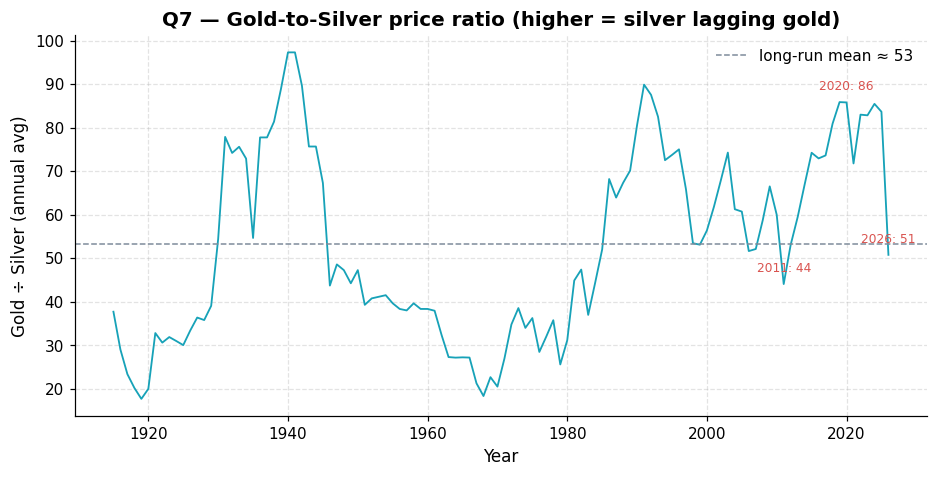

In [7]:
# Supporting visual for Q7: gold-to-silver ratio (precious-metal co-movement vs amplitude)
ratio = (ga / sa).dropna()
fig, ax = plt.subplots()
ax.plot(ratio.index, ratio.values, color=dsb.COLORS["accent"], linewidth=1.2)
ax.axhline(ratio.mean(), color=dsb.COLORS["silver"], linestyle="--", linewidth=1,
           label=f"long-run mean ≈ {ratio.mean():.0f}")
for yr in [2011, 2020, 2026]:
    ax.annotate(f"{yr}: {ratio.loc[yr]:.0f}", (yr, ratio.loc[yr]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8, color=dsb.COLORS["cny"])
ax.set_title("Q7 — Gold-to-Silver price ratio (higher = silver lagging gold)")
ax.set_xlabel("Year"); ax.set_ylabel("Gold ÷ Silver (annual avg)"); ax.legend()
dsb.save_fig(fig, "PartII_Q7_gold_silver_ratio", QDIR); plt.show()

> **Cited Part I chart — Q16 Gold vs Silver (from `14-26Q`):**
>
> ![Q16 Gold vs Silver](../14-26Q/figures/Q16_gold_vs_silver.png)

### Q8 — Choose one crisis period and compare the behaviour of Oil, Gold and Silver.

saved table  -> part2/tables/PartII_Q8_crisis_comparison.csv
saved figure -> part2/figures/PartII_Q8_crisis_comparison.png


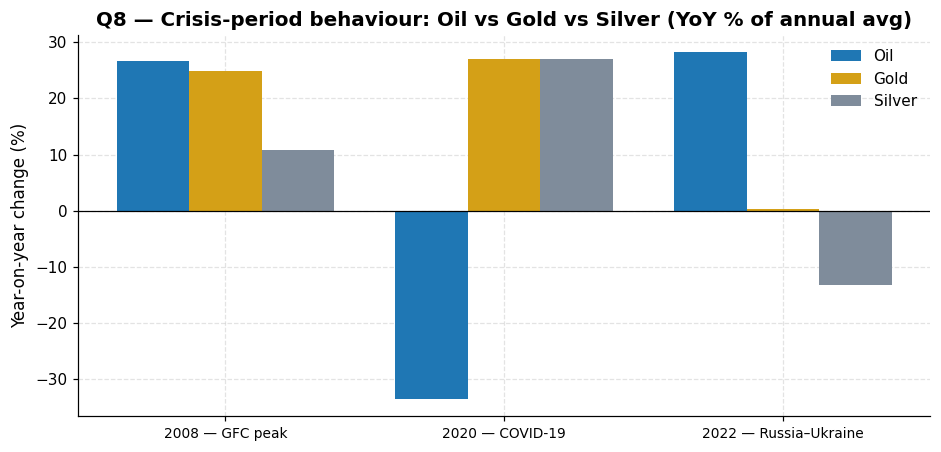

,Crisis (year),Oil YoY %,Gold YoY %,Silver YoY %
0,2008 — GFC peak,26.7,24.9,10.8
1,2020 — COVID-19,-33.6,27.0,27.1
2,2022 — Russia–Ukraine,28.2,0.3,-13.2


In [8]:
def yoy(series, year):
    return (series.loc[year] / series.loc[year - 1] - 1) * 100

crises = {"2008 — GFC peak": 2008, "2020 — COVID-19": 2020, "2022 — Russia–Ukraine": 2022}
rows = []
for label, yr in crises.items():
    rows.append({
        "Crisis (year)": label,
        "Oil YoY %":    round(yoy(ba, yr), 1),
        "Gold YoY %":   round(yoy(ga, yr), 1),
        "Silver YoY %": round(yoy(sa, yr), 1),
    })
crisis_cmp = pd.DataFrame(rows)
dsb.save_table(crisis_cmp, "PartII_Q8_crisis_comparison", QDIR)

# grouped bar chart of the comparison
fig, ax = plt.subplots()
x = np.arange(len(crisis_cmp)); w = 0.26
for i, (col, c) in enumerate([("Oil YoY %", dsb.COLORS["oil"]),
                              ("Gold YoY %", dsb.COLORS["gold"]),
                              ("Silver YoY %", dsb.COLORS["silver"])]):
    ax.bar(x + (i - 1) * w, crisis_cmp[col], width=w, color=c, label=col.replace(" YoY %", ""))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(crisis_cmp["Crisis (year)"], fontsize=9)
ax.set_title("Q8 — Crisis-period behaviour: Oil vs Gold vs Silver (YoY % of annual avg)")
ax.set_ylabel("Year-on-year change (%)"); ax.legend()
dsb.save_fig(fig, "PartII_Q8_crisis_comparison", QDIR); plt.show()
crisis_cmp

The comparison table shows which crises hit through supply and which hit through fear. In 2020 (COVID) the split is textbook: oil fell 33.6% on collapsing demand while gold and silver rose 27.0% and 27.1% as safe havens, moving opposite to oil. In 2022 (Russia-Ukraine) the pattern flips: oil rose 28.2% on a supply/sanctions shock, while gold was roughly flat (+0.3%) and silver actually fell 13.2%, because this was an energy-supply story rather than a flight to safety. 2008 sits in between - oil rose 26.7% into its mid-year peak while gold also gained 24.9% on early-crisis fear. The takeaway for risk management: oil reacts to supply, the metals react to fear, and the two don't always move together.

> **Cited Part I chart — Q28 2020 crisis (from `27-30Q`):**
>
> ![Q28 crisis 2020](../27-30Q/figures/q28_crisis_2020.png)

---
## C. Linking Events to Currency Data

### Q9 — How does the Global Currency Tracker show the role of USD in international payments?

In [9]:
gps = dsb.global_payment_share(swift)          # April 2026 report
tfs = dsb.trade_finance_share(swift)
exeu = swift[(swift.metric == "International Payment Share (ex-Eurozone)") &
             (swift.report_month == dsb.RECENT_REPORT)].sort_values("value", ascending=False)
usd_pay = gps.loc[gps.currency_or_economy == "USD", "value"].iloc[0]
usd_tf  = tfs.loc[tfs.currency_or_economy == "USD", "value"].iloc[0]
usd_ex  = exeu.loc[exeu.currency_or_economy == "USD", "value"].iloc[0]
print(f"USD — Global Payment Share: {usd_pay:.2f}% (rank 1)")
print(f"USD — Trade Finance Share:  {usd_tf:.2f}% (rank 1)")
print(f"USD — Intl Payments ex-Eurozone: {usd_ex:.2f}% (rank 1)")

USD — Global Payment Share: 51.14% (rank 1)
USD — Trade Finance Share:  80.73% (rank 1)
USD — Intl Payments ex-Eurozone: 58.50% (rank 1)


USD is clearly the dominant settlement currency in the tracker. In the most recent report (April 2026) it holds 51.14% of SWIFT global payments, ranked first, and its lead is even larger in trade finance at 80.73%. Once intra-Eurozone euro payments are excluded, USD's share of genuinely international payments rises to 58.50%. The euro is a distant second at around 21%, so on this data the dollar is still the backbone of cross-border settlement.

> **Cited Part I chart — Q24 Top-10 currencies (from `14-26Q`):**
>
> ![Q24 top currencies](../14-26Q/figures/Q24_top10_currencies.png)

### Q10 — What does the tracker show about the role of CNY/RMB in global payments and trade finance?

saved table  -> part2/tables/PartII_Q10_usd_vs_cny.csv


saved figure -> part2/figures/PartII_Q10_usd_vs_cny.png


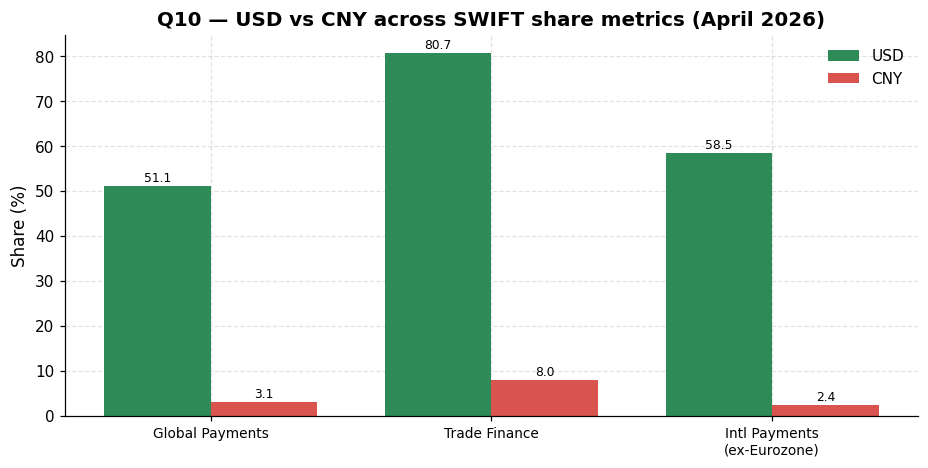

CNY payments 3.10% (rank 5) | trade finance 8.04% (rank 2)


In [10]:
cny_pay = gps.loc[gps.currency_or_economy == "CNY"].iloc[0]
cny_tf  = tfs.loc[tfs.currency_or_economy == "CNY", "value"].iloc[0]
cny_tf_rank = int((tfs["value"] > cny_tf).sum() + 1)
cny_ex  = exeu.loc[exeu.currency_or_economy == "CNY"].iloc[0]

# Supporting visual: USD vs CNY across the three SWIFT share metrics
metrics = ["Global Payments", "Trade Finance", "Intl Payments\n(ex-Eurozone)"]
usd_vals = [usd_pay, usd_tf, usd_ex]
cny_vals = [cny_pay["value"], cny_tf, cny_ex["value"]]
q10 = pd.DataFrame({"Metric": ["Global Payment Share", "Trade Finance Share",
                               "Intl Payment Share (ex-Eurozone)"],
                    "USD %": [round(v, 2) for v in usd_vals],
                    "CNY %": [round(v, 2) for v in cny_vals]})
dsb.save_table(q10, "PartII_Q10_usd_vs_cny", QDIR)

x = np.arange(len(metrics)); w = 0.38
fig, ax = plt.subplots()
ax.bar(x - w/2, usd_vals, width=w, color=dsb.COLORS["usd"], label="USD")
ax.bar(x + w/2, cny_vals, width=w, color=dsb.COLORS["cny"], label="CNY")
for xi, (u, c) in enumerate(zip(usd_vals, cny_vals)):
    ax.text(xi - w/2, u + 1, f"{u:.1f}", ha="center", fontsize=8)
    ax.text(xi + w/2, c + 1, f"{c:.1f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=9)
ax.set_title(f"Q10 — USD vs CNY across SWIFT share metrics ({dsb.RECENT_REPORT})")
ax.set_ylabel("Share (%)"); ax.legend()
dsb.save_fig(fig, "PartII_Q10_usd_vs_cny", QDIR); plt.show()
print(f"CNY payments {cny_pay['value']:.2f}% (rank {int(cny_pay['rmb_global_rank'])}) | "
      f"trade finance {cny_tf:.2f}% (rank {cny_tf_rank})")

RMB plays a small role in general payments but a bigger one in trade. In April 2026 CNY holds just 3.10% of global payments (rank 5), an order of magnitude below USD, yet it's the second-largest trade-finance currency at 8.04%, behind only the dollar. That gap says something: China's currency is internationalising mainly through trade and bilateral settlement, where Beijing has more direct influence, rather than through everyday payments. There's also some momentum - RMB payments grew 12.65% and 11.44% month-on-month in the January and February 2026 reports.

### Q11 — Why might sanctions, alternative settlement systems, or BRICS Pay discussions matter?

They matter because dollar-based SWIFT settlement is also a point of leverage - and a single point of failure. When a country is cut off from SWIFT, as Russia largely was after 2022, it has to settle trade elsewhere, which is close to what the data shows: RMB trade-finance share has climbed to 8.04% (rank 2) and RMB payments were growing 11-13% month-on-month in early 2026. Alternative rails like CIPS and BRICS Pay, plus the 2022-2026 wave of central-bank gold buying, point the same direction - reducing reliance on a payment system that can be weaponised. It's a slow-moving risk rather than an urgent one (USD is still at roughly 51%), but the direction of travel matters for anyone thinking about sanctions exposure or reserve strategy.

### Q12 — What does the offshore RMB data suggest about Hong Kong and other financial centres?

In [11]:
off = dsb.offshore_rmb(swift)
print("Offshore RMB by economy (April 2026), top 5:")
print(off[["currency_or_economy", "value"]].head(5).to_string(index=False))
hk = off.iloc[0]
print(f"\nHong Kong leads at {hk['value']:.2f}%; next is {off.iloc[1]['currency_or_economy']} "
      f"at {off.iloc[1]['value']:.2f}%")

Offshore RMB by economy (April 2026), top 5:
currency_or_economy  value
          Hong Kong  75.23
     United Kingdom   6.90
          Singapore   4.37
      United States   2.81
             France   1.80

Hong Kong leads at 75.23%; next is United Kingdom at 6.90%


Offshore RMB activity is heavily concentrated in one place: Hong Kong holds 75.23% of it (April 2026), more than ten times the next centre, the UK (6.90%), with Singapore third at 4.37%. So even as China promotes the RMB internationally, the offshore plumbing still runs mostly through Hong Kong as the gateway between onshore China and world markets. That's an advantage for Hong Kong as a financial centre, but it's also a concentration risk - any disruption there (regulatory, geopolitical, operational) would bottleneck most offshore RMB flows, since London and Singapore remain comparatively minor by volume.

> **Cited Part I table — Q23 Offshore RMB leaders (from `14-26Q/tables/Q23_offshore_rmb.csv`).**

---
## D. Business Interpretation & Recommendation

### Q13 — Which market looks most sensitive to global events: Oil, Gold, Silver or currencies?

In [12]:
# Sensitivity table: amplitude (CV) + speed (largest 1-month move) + largest annual move
def sens(name, d, ann):
    cv = d["Value"].std() / d["Value"].mean() * 100
    mom = d["Value"].pct_change().abs().max() * 100
    yoy_max = ann.pct_change().abs().max() * 100
    return {"Market": name, "CV % (amplitude)": round(cv, 1),
            "Max 1-month move %": round(mom, 1), "Max annual move %": round(yoy_max, 1)}

# currencies: use the spread of USD's monthly global-payment share across the 4 reports as a proxy
usd_series = swift[(swift.metric == "Global Payment Share") &
                   (swift.currency_or_economy == "USD")].sort_values("report_month")["value"]
cur_cv = usd_series.std() / usd_series.mean() * 100

sensitivity = pd.DataFrame([
    sens("Brent Oil", brent, ba),
    sens("Gold", gold, ga),
    sens("Silver", silver, sa),
    {"Market": "USD payment share", "CV % (amplitude)": round(cur_cv, 1),
     "Max 1-month move %": None, "Max annual move %": None},
])
dsb.save_table(sensitivity, "PartII_Q13_sensitivity", QDIR)
sensitivity

saved table  -> part2/tables/PartII_Q13_sensitivity.csv


,Market,CV % (amplitude),Max 1-month move %,Max annual move %
0,Brent Oil,57.4,132.5,141.5
1,Gold,163.9,32.2,89.3
2,Silver,154.1,69.5,131.5
3,USD payment share,1.7,NaN,NaN


Sensitivity isn't one thing here - it splits into amplitude and speed. On amplitude, the metals win: gold and silver have coefficients of variation around 164% and 154% versus oil's 57%, and silver alone moved +131% in 2026. On speed, oil wins: it can re-price within days of a single event, like the 52% jump in March 2026, while the metals' big moves are slower, multi-year climbs. Currencies are the least sensitive of the four - USD's payment share barely moves across the four available reports. So the honest answer is: oil reacts fastest to sudden shocks, gold and silver show the largest sustained swings over time, and currency shares shift the slowest.

> **Cited Part I chart — Q27 volatility comparison (from `27-30Q`):**
>
> ![Q27 volatility](../27-30Q/figures/q27_volatility_comparison.png)

### Q14 — Risk note for a company exposed to oil prices

A company exposed to oil prices faces real, event-driven volatility. Brent's own record shows it: a 2020 COVID collapse (annual average down 33.6%, to about \$49), a 2022 Russia-Ukraine surge (up 28.2%, to about \$106), and, most recently, a jump from \$67.66 to \$102.86 in a single month (Feb-Mar 2026, +52%) tied to Strait of Hormuz disruption (Q13, Q5). Because oil reacts to supply shocks within days, costs can outrun budgets or contracts before anyone adjusts. The main risks are margin compression for fuel-intensive operations, working-capital strain during spikes, and demand destruction if high prices persist. It runs both ways too - a sudden glut (2015-16, 2020) can just as easily hurt producer revenue. Hedging, flexible pricing clauses, and budgeting for plus-or-minus 30% annual swings are all sensible.

### Q15 — Risk note for a company holding assets in USD, Gold or RMB/CNY

A company holding USD, gold or RMB/CNY assets is taking on three different risk profiles. USD remains safest for liquidity and settlement - it still handles 51.14% of SWIFT payments and 80.73% of trade finance (April 2026, Q9) - but it earns no crisis premium and can soften when US rates fall. Gold has been the standout: its annual average roughly tripled from about \$1,799 (2022) to \$4,882 (2026, Q4/Q14), making it an effective geopolitical hedge, though it pays no yield and can correct sharply. RMB/CNY offers exposure to China's growing trade-finance role (8.04%, rank 2, Q10) but its payment share is still small (3.10%, rank 5), concentrated in offshore Hong Kong (75.23%, Q12), and carries policy and convertibility risk. Spreading exposure across all three balances liquidity, safety and growth rather than leaning on just one.

### Q16 — Three practical recommendations for investors, companies or policymakers

Based on the Part I evidence and the event linkages above:

1. **Hedge oil exposure explicitly and budget for ±30% swings.** Oil is the most event-sensitive
   market (Q13): a single supply shock moved Brent **+52% in one month** (Mar 2026, Q5). Fuel-intensive
   businesses should lock in forward/option hedges and build flexible fuel-surcharge clauses rather
   than assume stable energy costs.

2. **Treat gold as a strategic reserve allocation, not a trade.** Gold's **~3× rise from 2022 to 2026**
   (Q4, Q11) is a multi-year structural climb driven by central-bank accumulation and de-dollarisation,
   not a spike. A standing allocation (e.g. 5–10%) hedges geopolitical and monetary risk; silver can
   add upside but expect larger drawdowns (Q7, Q27).

3. **Monitor RMB trade-finance growth and diversify settlement.** The dollar still dominates (51.1%,
   Q9), but RMB is now the **#2 trade-finance currency (8.0%)** and growing double-digits month-on-month
   (Q10–Q11). Companies trading with China/BRICS should track CNY liquidity, offshore Hong Kong clearing
   (Q12), and keep optionality across settlement currencies to manage sanctions and concentration risk.

---
### Part II artifacts


In [15]:
import os
print("PartII figures:", sorted(os.listdir(os.path.join(QDIR, "figures"))))
print("PartII tables: ", sorted(os.listdir(os.path.join(QDIR, "tables"))))

PartII figures: ['PartII_Q10_usd_vs_cny.png', 'PartII_Q4_gold_accumulation.png', 'PartII_Q5_brent_recent.png', 'PartII_Q7_gold_silver_ratio.png', 'PartII_Q8_crisis_comparison.png', 'pt2_q2_timeline_oil.png', 'pt2_q3_russia_ukraine_oil.png']
PartII tables:  ['PartII_Q10_usd_vs_cny.csv', 'PartII_Q13_sensitivity.csv', 'PartII_Q2_event_timeline.csv', 'PartII_Q8_crisis_comparison.csv']
